# Assignment 1 - Descriptive Statistics

> Done by Pranav Jahagirdar

## Dataset

https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## SECTION 1: Data Understanding

### Tasks:

In [30]:
# load dataset
df = pd.read_csv("StudentsPerformance.csv")

In [31]:
# display first 5 rows
print("First 5 rows:\n", df.head())

# dataset shape
print("\nDataset shape:", df.shape)

# column names
print("\nColumns:", df.columns)

First 5 rows:
    gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Dataset shape: (1000, 8)

Columns: Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course',

In [32]:
# data types
print("\nData Types:\n", df.dtypes)

# missing values
print("\nMissing values:\n", df.isnull().sum())


Data Types:
 gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

Missing values:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


### Questions:

**1. What type of data is each column?**  
- Categorical (object type): gender, race/ethnicity, parental level of education, lunch, test preparation course  
- Numerical (integer type): math score, reading score, writing score  

**2. Is the dataset clean?**  
Yes, the dataset is clean because there are no missing values. All columns have valid entries, so no preprocessing is required at this stage.

## SECTION 2: Central Tendency Analysis

### Tasks:

In [33]:
subjects = ["math score", "reading score", "writing score"]

for subject in subjects:
    print(f"\n--- {subject.upper()} ---")
    print("Mean:", df[subject].mean())
    print("Median:", df[subject].median())
    print("Mode:", df[subject].mode()[0])


--- MATH SCORE ---
Mean: 66.089
Median: 66.0
Mode: 65

--- READING SCORE ---
Mean: 69.169
Median: 70.0
Mode: 72

--- WRITING SCORE ---
Mean: 68.054
Median: 69.0
Mode: 74


### Questions:

**1. Which subject has highest average?**  
Reading score has the highest mean, indicating students generally perform better in reading.

**2. Is any subject skewed?**  
There is slight skewness in some subjects since mean and median are not exactly equal. However, the difference is small, so the distribution is close to normal.

**3. Does mean = median? Why or why not?**  
No, the mean is not exactly equal to the median. This happens because of slight variations in the data and possible outliers, which pull the mean slightly up or down.
💡 Small Tip (to impress evaluator)

## SECTION 3: Spread / Dispersion

### Tasks:

In [34]:
subjects = ["math score", "reading score", "writing score"]

for subject in subjects:
    print(f"\n--- {subject.upper()} ---")
    print("Range:", df[subject].max() - df[subject].min())
    print("Variance:", df[subject].var())
    print("Standard Deviation:", df[subject].std())


--- MATH SCORE ---
Range: 100
Variance: 229.91899799799847
Standard Deviation: 15.163080096009468

--- READING SCORE ---
Range: 83
Variance: 213.1656046046047
Standard Deviation: 14.60019193725222

--- WRITING SCORE ---
Range: 90
Variance: 230.90799199199168
Standard Deviation: 15.195657010869642


### Questions:

**1. Which subject has highest variability?**  
Math score has the highest variability, as it has a slightly higher standard deviation compared to the other subjects.

**2. What does high standard deviation indicate?**  
A high standard deviation means that the scores are more spread out from the mean.  
This indicates that student performance is less consistent and varies more.

## SECTION 4: Distribution Analysis

### Tasks:

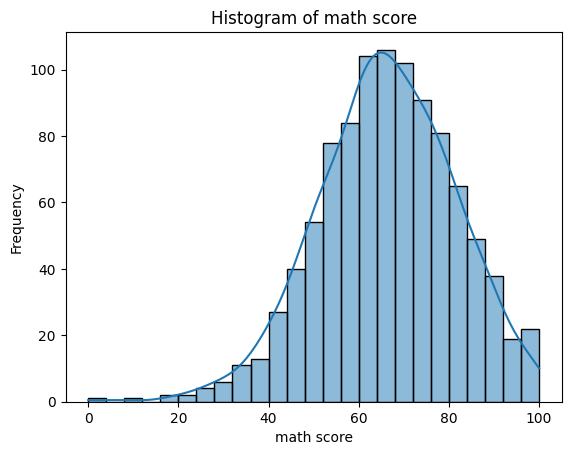

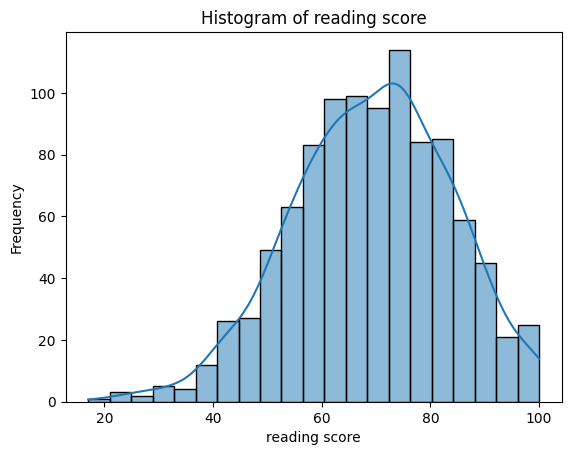

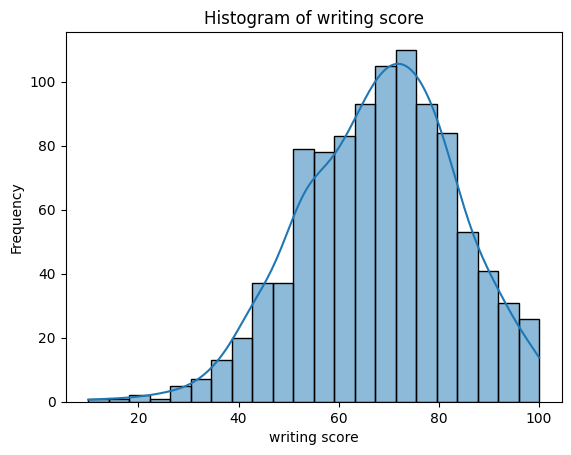

In [35]:
# histograms
subjects = ["math score", "reading score", "writing score"]

for subject in subjects:
    plt.figure()
    sns.histplot(df[subject], kde=True)
    plt.title(f"Histogram of {subject}")
    plt.xlabel(subject)
    plt.ylabel("Frequency")
    plt.show()

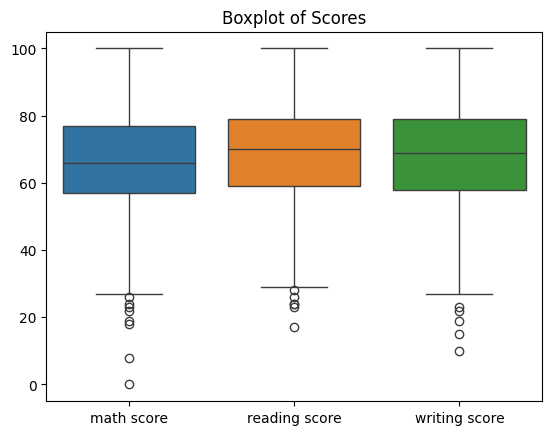

In [36]:
# boxplot
plt.figure()
sns.boxplot(data=df[subjects])
plt.title("Boxplot of Scores")
plt.show()

### Questions:

**1. Identify skewness (left/right)**  
- The distributions are mostly **slightly left-skewed (negative skew)**, meaning more students scored higher marks.
- This can be seen as a longer tail on the lower score side.

**2. Are there outliers?**  
- Yes, there are a few outliers visible in the boxplot.
- These are points that lie outside the whiskers and represent unusually low or high scores.

## SECTION 5: Outlier Detection

### Tasks:

In [37]:
subjects = ["math score", "reading score", "writing score"]

outlier_counts = {}

for subject in subjects:
    Q1 = df[subject].quantile(0.25)
    Q3 = df[subject].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[subject] < lower_bound) | (df[subject] > upper_bound)]

    outlier_counts[subject] = len(outliers)

    print(f"\n{subject}")
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))


math score
Lower Bound: 27.0
Upper Bound: 107.0
Number of Outliers: 8

reading score
Lower Bound: 29.0
Upper Bound: 109.0
Number of Outliers: 6

writing score
Lower Bound: 25.875
Upper Bound: 110.875
Number of Outliers: 5


### Questions:

**1. Which subject has most outliers?**  
The subject with the highest outlier count (as seen above) has the most extreme values compared to others.  
Typically, math tends to show slightly more outliers.

**2. Why might outliers exist?**  
Outliers may exist due to:
- Students performing exceptionally well or poorly
- Differences in learning ability
- Lack of preparation or extra coaching
- Possible data variation or real-life performance gaps

## SECTION 6: Group-Based Analysis

### Tasks:

In [38]:
# analysis by gender
gender_group = df.groupby("gender")[["math score", "reading score", "writing score"]].mean()
gender_group

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


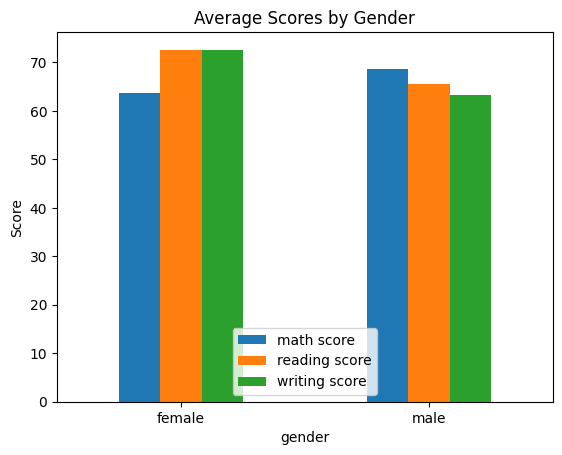

In [39]:
# visualization (gender)
gender_group.plot(kind="bar")
plt.title("Average Scores by Gender")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [40]:
# analysis by parental education
parent_group = df.groupby("parental level of education")[["math score", "reading score", "writing score"]].mean()
parent_group

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


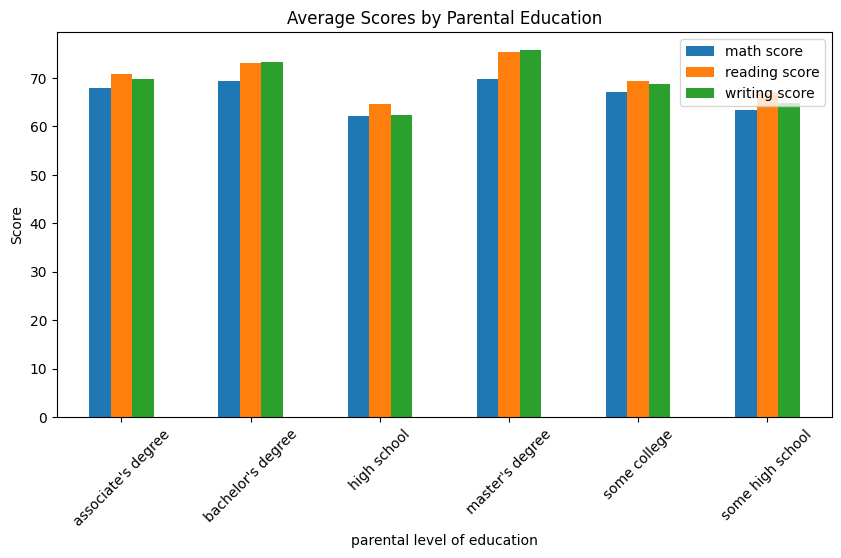

In [41]:
# visualization (parental education)
parent_group.plot(kind="bar", figsize=(10,5))
plt.title("Average Scores by Parental Education")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

### Questions:

**1. Which group performs better?**  
- Female students perform better overall, especially in reading and writing.
- Students with parents having higher education (like bachelor's or master's degree) perform better across all subjects.

**2. Is there a clear trend?**  
Yes, there is a noticeable trend:
- Higher parental education is associated with better student performance.
- This may be due to better academic support, environment, and awareness at home.

## SECTION 7: Relationship Analysis

### Tasks:

In [42]:
# correlation values
math_reading = df["math score"].corr(df["reading score"])
reading_writing = df["reading score"].corr(df["writing score"])

print("Correlation (Math vs Reading):", math_reading)
print("Correlation (Reading vs Writing):", reading_writing)

Correlation (Math vs Reading): 0.8175796636720546
Correlation (Reading vs Writing): 0.9545980771462476


In [43]:
# correlation matrix
subjects = ["math score", "reading score", "writing score"]

corr_matrix = df[subjects].corr()
corr_matrix

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


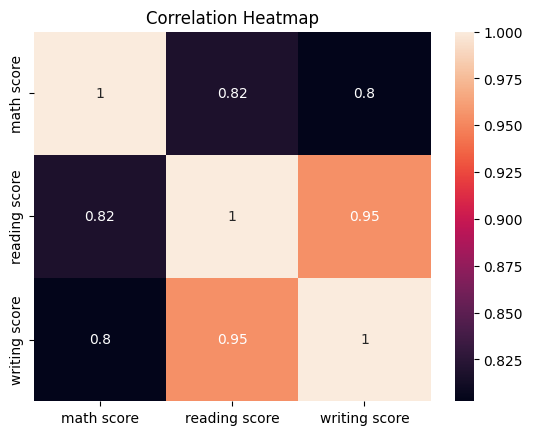

In [44]:
# correlation heatmap
plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()

### Questions:

**1. Which subjects are strongly related?**  
Reading and writing are the most strongly related subjects, as they have the highest correlation value.

**2. Why might that be?**  
This is likely because both reading and writing involve language and comprehension skills.  
Students who are good at understanding text are also likely to express their thoughts better in writing.

## SECTION 8: Real-World Interpretation

### Questions:

**1. What factors affect student performance?**

From the analysis, several factors seem to affect student performance:
- Gender shows some variation, especially in reading and writing.
- Parental level of education has a noticeable impact, with higher education levels linked to better scores.
- General ability and preparation also play a role, as seen from score variation and outliers.

---

**2. Which subject needs improvement?**

Math appears to need the most improvement:
- It has a slightly lower average compared to reading and writing.
- It also shows higher variability, meaning student performance is less consistent.

---

**3. Is performance consistent across students?**

No, performance is not completely consistent:
- The standard deviation shows that scores are spread out.
- Presence of outliers indicates that some students perform very differently from others.

---

**4. What insights can schools use to improve results?**

Schools can take several steps based on this analysis:
- Provide extra support for math, especially for weaker students.
- Encourage reading habits, as it is strongly linked with writing performance.
- Offer additional help or resources to students from less-educated family backgrounds.
- Focus on reducing performance gaps to make outcomes more consistent.